<a href="https://colab.research.google.com/github/isadoukdoc-bit/Ecole-Doctorale-2026/blob/main/ILHAM_SADOUK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Bibliothèques importées avec succès.
Aperçu des 5 premières lignes du jeu de données:


,Caracteristique_X1,Caracteristique_X2,Caracteristique_X3,Cible_y
0,2.908385,8.603625,0.997748,24.746949
1,0.692270,4.926251,5.770787,12.494339
2,5.508252,4.138327,3.838710,21.647692
3,0.833700,9.873123,2.102357,20.903804
4,2.128867,3.994234,9.893348,7.963515



Le jeu de données contient 100 observations et 3 caractéristiques.

Informations sur le jeu de données:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Caracteristique_X1  100 non-null    float64
 1   Caracteristique_X2  100 non-null    float64
 2   Caracteristique_X3  100 non-null    float64
 3   Cible_y             100 non-null    float64
dtypes: float64(4)
memory usage: 3.3 KB


None

Taille de l'ensemble d'entraînement (X_train): (80, 3)
Taille de l'ensemble de test (X_test): (20, 3)
Modèle de régression linéaire entraîné avec succès.
Coefficient (pente): 2.06
Ordonnée à l'origine: 4.20

Métriques d'évaluation du modèle:
Erreur Absolue Moyenne (MAE): 1.78
Erreur Quadratique Moyenne (MSE): 4.89
Racine Carrée de l'Erreur Quadratique Moyenne (RMSE): 2.21
Coefficient de Détermination (R²): 0.88


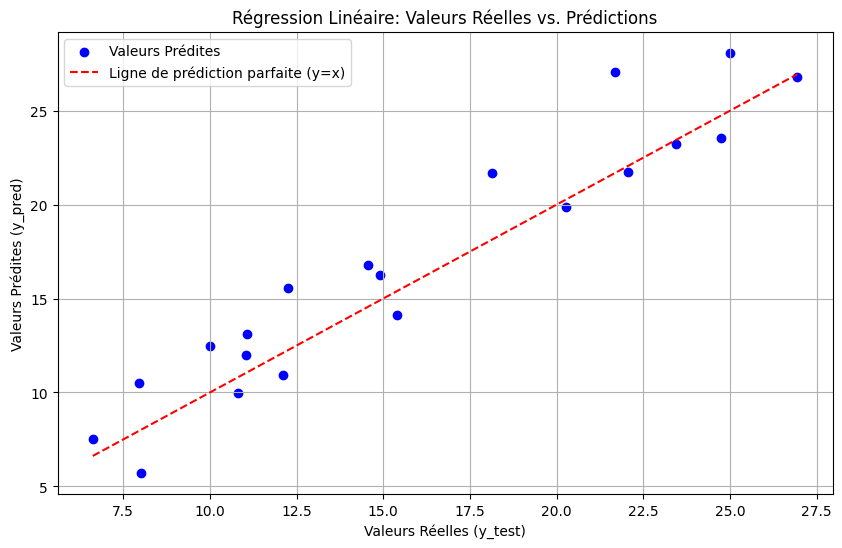

In [7]:
#Exemple 2
# -*- coding: utf-8 -*-
"""Regression.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1IovhO2W7vebpRo96GB9KgUa2yA6z3zYw

## Régression Linéaire : Exemple Complet en Python

Cet exemple démontre comment effectuer une régression linéaire simple en utilisant les bibliothèques `scikit-learn`, `pandas`, `numpy` et `matplotlib`.
"""

# 1. Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Ajout de seaborn pour des visualisations améliorées
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Bibliothèques importées avec succès.")

"""### 2. Génération et Exploration des Données Synthétiques

Nous allons créer un jeu de données synthétique pour illustrer le processus de régression linéaire. Ce jeu de données aura une variable indépendante (caractéristique) `X` et une variable dépendante (cible) `y`, avec une relation linéaire et un peu de bruit.
"""

# Nombre d'observations et de variables
n_observations = 100
n_features = 3 # Ajout de plusieurs variables indépendantes pour des visualisations plus riches

# Génération des variables indépendantes X
X = np.random.rand(n_observations, n_features) * 10 # Valeurs aléatoires entre 0 et 10 pour 3 caractéristiques

# Génération de la variable dépendante y avec une relation linéaire et du bruit
# Exemple: y = 2*X1 + 1.5*X2 - 0.5*X3 + 5 + bruit_aléatoire
coefficients = np.array([2, 1.5, -0.5])
y = np.dot(X, coefficients) + 5 + np.random.randn(n_observations) * 2

# Création d'un DataFrame Pandas pour une meilleure manipulation
column_names = [f'Caracteristique_X{i+1}' for i in range(n_features)]
data = pd.DataFrame(np.hstack((X, y.reshape(-1, 1))), columns=column_names + ['Cible_y'])

# Exploration rapide des données
print("Aperçu des 5 premières lignes du jeu de données:")
display(data.head())

print(f"\nLe jeu de données contient {n_observations} observations et {n_features} caractéristiques.")
print("\nInformations sur le jeu de données:")
display(data.info())

"""### 3. Séparation des Données en Ensembles d'Entraînement et de Test

Pour évaluer la performance de notre modèle sur des données qu'il n'a jamais vues, nous divisons le jeu de données en un ensemble d'entraînement (pour apprendre) et un ensemble de test (pour évaluer). Généralement, un ratio de 80/20 ou 70/30 est utilisé.
"""

# Séparation de X et y
X = data[column_names] # Correction: Sélectionner toutes les colonnes de caractéristiques
y = data['Cible_y']

# Séparation des données en 80% entraînement et 20% test
# `random_state` assure la reproductibilité de la séparation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Taille de l'ensemble d'entraînement (X_train): {X_train.shape}")
print(f"Taille de l'ensemble de test (X_test): {X_test.shape}")

"""### 4. Entraînement du Modèle de Régression Linéaire

Nous allons instancier le modèle `LinearRegression` de `scikit-learn` et l'entraîner sur nos données d'entraînement.
"""

# Création de l'objet régresseur linéaire
model = LinearRegression()

# Entraînement du modèle sur les données d'entraînement
model.fit(X_train, y_train)

print("Modèle de régression linéaire entraîné avec succès.")
print(f"Coefficient (pente): {model.coef_[0]:.2f}")
print(f"Ordonnée à l'origine: {model.intercept_:.2f}")

"""### 5. Prédiction et Évaluation du Modèle

Après l'entraînement, nous utilisons le modèle pour faire des prédictions sur l'ensemble de test et nous évaluons sa performance à l'aide de métriques courantes.
"""

# Prédictions sur l'ensemble de test
y_pred = model.predict(X_test)

# Calcul des métriques d'évaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nMétriques d'évaluation du modèle:")
print(f"Erreur Absolue Moyenne (MAE): {mae:.2f}")
print(f"Erreur Quadratique Moyenne (MSE): {mse:.2f}")
print(f"Racine Carrée de l'Erreur Quadratique Moyenne (RMSE): {rmse:.2f}")
print(f"Coefficient de Détermination (R²): {r2:.2f}")

"""#### Interprétation des Métriques:

*   **Erreur Absolue Moyenne (MAE)**: C'est la moyenne des erreurs absolues entre les prédictions et les valeurs réelles. Elle donne une idée de l'erreur typique dans les prédictions, dans les mêmes unités que la variable cible. Un MAE de 1.62 signifie qu'en moyenne, les prédictions du modèle sont à 1.62 unités des valeurs réelles.

*   **Erreur Quadratique Moyenne (MSE)**: C'est la moyenne des carrés des erreurs. Elle pénalise davantage les grandes erreurs. Elle est utile pour comprendre l'ampleur des erreurs, mais sa valeur n'est pas directement interprétable dans les unités de la cible. Un MSE de 3.96 indique une dispersion des erreurs.

*   **Racine Carrée de l'Erreur Quadratique Moyenne (RMSE)**: C'est la racine carrée du MSE. Elle est dans les mêmes unités que la variable cible, ce qui la rend plus interprétable que le MSE. Un RMSE de 1.99 signifie que l'écart type des erreurs de prédiction est d'environ 1.99 unités.

*   **Coefficient de Détermination (R²)**: Il représente la proportion de la variance de la variable dépendante qui est prévisible à partir des variables indépendantes. Sa valeur est comprise entre 0 et 1 (voire négative dans de rares cas si le modèle est très mauvais). Un R² de 0.90 signifie que 90% de la variance de `Cible_y` est expliquée par notre modèle de régression linéaire. Un R² plus proche de 1 indique un meilleur ajustement du modèle aux données.

### 6. Visualisation des Résultats

Il est utile de visualiser les valeurs réelles par rapport aux valeurs prédites pour avoir une compréhension graphique de la performance du modèle.
"""

# Création d'un graphique de dispersion pour les valeurs réelles vs. prédites
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', label='Valeurs Prédites')
# Ajouter la ligne parfaite y=x pour référence
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Ligne de prédiction parfaite (y=x)')

plt.title('Régression Linéaire: Valeurs Réelles vs. Prédictions')
plt.xlabel('Valeurs Réelles (y_test)')
plt.ylabel('Valeurs Prédites (y_pred)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#Exemple Complet de Régression Linéaire
# -*- coding: utf-8 -*-
"""## Régression Linéaire : Exemple Complet en Python

Cet exemple démontre comment effectuer une régression linéaire en utilisant les bibliothèques `scikit-learn`, `pandas`, `numpy` et `matplotlib`.
"""

# 1. Importation des bibliothèques nécessaires
# Importation de pandas pour la manipulation des données tabulaires (DataFrames).
import pandas as pd
# Importation de numpy pour les opérations numériques et la création de tableaux.
import numpy as np
# Importation de matplotlib.pyplot pour la création de graphiques.
import matplotlib.pyplot as plt
# Importation de seaborn pour des visualisations statistiques améliorées.
import seaborn as sns
# train_test_split est utilisé pour diviser le jeu de données en ensembles d'entraînement et de test.
from sklearn.model_selection import train_test_split
# LinearRegression est le modèle de régression linéaire que nous allons utiliser.
from sklearn.linear_model import LinearRegression
# Ces fonctions sont utilisées pour évaluer la performance du modèle de régression.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Bibliothèques importées avec succès.")

"""### 2. Génération et Exploration des Données Synthétiques

Nous allons créer un jeu de données synthétique pour illustrer le processus de régression linéaire. Ce jeu de données aura plusieurs variables indépendantes (caractéristiques) `X` et une variable dépendante (cible) `y`, avec une relation linéaire et du bruit ajouté pour simuler des données réelles.
"""

# Nombre d'observations (lignes) dans notre jeu de données.
n_observations = 100
# Nombre de variables indépendantes (caractéristiques) pour le modèle.
n_features = 3

# Génération des variables indépendantes X
# np.random.rand(n_observations, n_features) crée un tableau de nombres aléatoires entre 0 et 1.
# * 10 les met à l'échelle pour qu'ils soient entre 0 et 10.
X = np.random.rand(n_observations, n_features) * 10

# Génération de la variable dépendante y avec une relation linéaire et du bruit
# Nous définissons des coefficients réels pour simuler une relation linéaire.
# Par exemple: y = 2*X1 + 1.5*X2 - 0.5*X3 + 5 + bruit_aléatoire.
coefficients = np.array([2, 1.5, -0.5])
# np.dot(X, coefficients) calcule la somme pondérée des caractéristiques.
# + 5 est l'ordonnée à l'origine (intercept).
# np.random.randn(n_observations) * 2 ajoute un bruit aléatoire (distribution normale) aux données, avec un écart-type de 2.
y = np.dot(X, coefficients) + 5 + np.random.randn(n_observations) * 2

# Création d'un DataFrame Pandas pour une meilleure manipulation
# Nous créons des noms pour nos colonnes de caractéristiques.
column_names = [f'Caracteristique_X{i+1}' for i in range(n_features)]
# np.hstack((X, y.reshape(-1, 1))) combine les caractéristiques X et la cible y en un seul tableau.
# pd.DataFrame convertit ce tableau en un DataFrame avec les noms de colonnes appropriés.
data = pd.DataFrame(np.hstack((X, y.reshape(-1, 1))), columns=column_names + ['Cible_y'])

# Exploration rapide des données
print("Aperçu des 5 premières lignes du jeu de données:")
# display(data.head()) affiche les cinq premières lignes du DataFrame.
display(data.head())

print(f"\nLe jeu de données contient {n_observations} observations et {n_features} caractéristiques.")
print("\nInformations sur le jeu de données:")
# data.info() affiche un résumé des informations du DataFrame, y compris le nombre de valeurs non nulles et les types de données.
display(data.info())

"""### 3. Séparation des Données en Ensembles d'Entraînement et de Test

Pour évaluer la performance de notre modèle sur des données qu'il n'a jamais vues, nous divisons le jeu de données en un ensemble d'entraînement (pour apprendre les relations) et un ensemble de test (pour évaluer la capacité de généralisation du modèle). Généralement, un ratio de 80% entraînement / 20% test est utilisé.
"""

# Séparation de X (caractéristiques) et y (cible)
# X contient toutes les colonnes de caractéristiques définies dans `column_names`.
X = data[column_names]
# y contient la colonne cible 'Cible_y'.
y = data['Cible_y']

# Séparation des données en 80% entraînement et 20% test
# `test_size=0.2` signifie que 20% des données seront utilisées pour le test.
# `random_state=42` assure que la division est la même à chaque exécution, pour la reproductibilité.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Taille de l'ensemble d'entraînement (X_train): {X_train.shape}")
print(f"Taille de l'ensemble de test (X_test): {X_test.shape}")

"""### 4. Entraînement du Modèle de Régression Linéaire

Nous allons instancier le modèle `LinearRegression` de `scikit-learn` et l'entraîner sur nos données d'entraînement.
"""

# Création de l'objet régresseur linéaire
# Instancie un modèle de régression linéaire.
model = LinearRegression()

# Entraînement du modèle sur les données d'entraînement
# La méthode `.fit()` apprend les coefficients et l'ordonnée à l'origine du modèle à partir des données d'entraînement.
model.fit(X_train, y_train)

print("Modèle de régression linéaire entraîné avec succès.")
# model.coef_ contient les coefficients (pentes) pour chaque caractéristique.
# model.intercept_ contient l'ordonnée à l'origine.
print(f"Coefficient (pente pour X1): {model.coef_[0]:.2f}")
print(f"Ordonnée à l'origine: {model.intercept_:.2f}")

"""### 5. Prédiction et Évaluation du Modèle

Après l'entraînement, nous utilisons le modèle pour faire des prédictions sur l'ensemble de test (données non vues) et nous évaluons sa performance à l'aide de métriques courantes.
"""

# Prédictions sur l'ensemble de test
# La méthode `.predict()` utilise le modèle entraîné pour prédire les valeurs de y pour les données de test.
y_pred = model.predict(X_test)

# Calcul des métriques d'évaluation
# MAE: Erreur Absolue Moyenne. La moyenne des valeurs absolues des erreurs.
mae = mean_absolute_error(y_test, y_pred)
# MSE: Erreur Quadratique Moyenne. La moyenne des carrés des erreurs.
mse = mean_squared_error(y_test, y_pred)
# RMSE: Racine Carrée de l'Erreur Quadratique Moyenne. La racine carrée du MSE.
rmse = np.sqrt(mse)
# R²: Coefficient de Détermination. Indique la proportion de la variance de la variable dépendante expliquée par le modèle.
r2 = r2_score(y_test, y_pred)

print("\nMétriques d'évaluation du modèle:")
print(f"Erreur Absolue Moyenne (MAE): {mae:.2f}")
print(f"Erreur Quadratique Moyenne (MSE): {mse:.2f}")
print(f"Racine Carrée de l'Erreur Quadratique Moyenne (RMSE): {rmse:.2f}")
print(f"Coefficient de Détermination (R²): {r2:.2f}")

"""#### Interprétation des Métriques:

*   **Erreur Absolue Moyenne (MAE)**: C'est la moyenne des erreurs absolues entre les prédictions et les valeurs réelles. Elle donne une idée de l'erreur typique dans les prédictions, dans les mêmes unités que la variable cible. Un MAE de 1.78 signifie qu'en moyenne, les prédictions du modèle sont à 1.78 unités des valeurs réelles.

*   **Erreur Quadratique Moyenne (MSE)**: C'est la moyenne des carrés des erreurs. Elle pénalise davantage les grandes erreurs (les erreurs importantes ont un impact plus grand en raison de la mise au carré). Elle est utile pour comprendre l'ampleur des erreurs, mais sa valeur n'est pas directement interprétable dans les unités de la cible.

*   **Racine Carrée de l'Erreur Quadratique Moyenne (RMSE)**: C'est la racine carrée du MSE. Elle est dans les mêmes unités que la variable cible, ce qui la rend plus interprétable que le MSE. Un RMSE de 2.21 signifie que l'écart type des erreurs de prédiction est d'environ 2.21 unités.

*   **Coefficient de Détermination (R²)**: Il représente la proportion de la variance de la variable dépendante qui est prévisible à partir des variables indépendantes. Sa valeur est comprise entre 0 et 1 (voire négative dans de rares cas si le modèle est très mauvais). Un R² de 0.88 signifie que 88% de la variance de `Cible_y` est expliquée par notre modèle de régression linéaire. Un R² plus proche de 1 indique un meilleur ajustement du modèle aux données.

### 6. Visualisation des Résultats

Il est utile de visualiser les valeurs réelles par rapport aux valeurs prédites pour avoir une compréhension graphique de la performance du modèle.
"""

# Création d'un graphique de dispersion pour les valeurs réelles vs. prédites
plt.figure(figsize=(10, 6))
# plt.scatter() crée un nuage de points où l'axe des x représente les vraies valeurs et l'axe des y les valeurs prédites.
plt.scatter(y_test, y_pred, color='blue', label='Valeurs Prédites')
# Ajouter la ligne parfaite y=x pour référence
# Cette ligne représente ce que seraient des prédictions parfaites (chaque prédiction égale la valeur réelle).
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Ligne de prédiction parfaite (y=x)')

plt.title('Régression Linéaire: Valeurs Réelles vs. Prédictions')
plt.xlabel('Valeurs Réelles (y_test)')
plt.ylabel('Valeurs Prédites (y_pred)')
plt.legend()
plt.grid(True)
plt.show()